In [5]:
# This notebook is 
#get common train/validation/test data
import pandas as pd
train_df = pd.read_csv("../covid/splits/train.csv")
val_df = pd.read_csv("../covid/splits/validation.csv")
test_df = pd.read_csv("../covid/splits/test.csv")

In [4]:
#%pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 891.6 kB/s eta 0:06:34
   ---------------------------------------- 0.5/351.2 MB 891.6 kB/s eta 0:06:34
   ---------------------------------------- 0.5/351.2 MB 891.6 kB/s eta 0:06:34
   ---------------------------------------- 1.0/351.2 MB 815.0 kB/s eta 0:07:10
   ---------------------------------------- 3.4/351.2 MB 2.9 MB/s eta 0:02:01
   ---------------------------------------- 3.4/351.2 MB 2.9 MB/s eta 0:02:01
   ---------------------------------------- 4.2/351.2 MB 2.5 MB/s eta 0:02:21
   ---------------------------------------- 4.2/351.2 MB 2.5 MB/s eta 0:02:21
   ---------------------------------------- 4.2/351.2 MB 2.5 MB/s eta 0:02:21
    --

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.36.1 which is incompatible.


In [3]:
import tensorflow as tf 
print(tf.__version__)

2.21.0


In [7]:
train_gen_df = train_df.copy()
val_gen_df = val_df.copy()
test_gen_df = test_df.copy()

train_gen_df["target"] = train_gen_df["target"].astype(str)
val_gen_df["target"] = val_gen_df["target"].astype(str)
test_gen_df["target"] = test_gen_df["target"].astype(str)

In [8]:
# Preprocessing commun aux trois jeux
## Préparation commune des données pour les expériences

#Les fichiers train.csv, validation.csv et test.csv ont été générés une seule fois
#dans le notebook d'exploration avec un split stratifié.

#Toutes les expériences utilisent ces mêmes fichiers afin de garantir
#la comparabilité des modèles.

#Préprocessing commun :
#- redimensionnement : 224 × 224
#- niveaux de gris : 1 canal
#- normalisation des pixels : [0, 1]

from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
COLOR_MODE = "L"

datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_gen_df,
    x_col="filepath",
    y_col="target",
    target_size=IMAGE_SIZE,
    color_mode="grayscale" if COLOR_MODE == "L" else "rgb",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=42
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_gen_df,
    x_col="filepath",
    y_col="target",
    target_size=IMAGE_SIZE,
    color_mode="grayscale" if COLOR_MODE == "L" else "rgb",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = datagen.flow_from_dataframe(
    dataframe=test_gen_df,
    x_col="filepath",
    y_col="target",
    target_size=IMAGE_SIZE,
    color_mode="grayscale" if COLOR_MODE == "L" else "rgb",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 13545 validated image filenames belonging to 2 classes.
Found 3387 validated image filenames belonging to 2 classes.
Found 4233 validated image filenames belonging to 2 classes.


In [9]:
images, labels = next(train_generator)

print("Shape images :", images.shape)
print("Shape labels :", labels.shape)
print("Pixel min :", images.min())
print("Pixel max :", images.max())
print("Labels :", labels[:10])

Shape images : (32, 224, 224, 1)
Shape labels : (32,)
Pixel min : 0.0
Pixel max : 1.0
Labels : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [10]:
# E0 — CNN baseline
#Sans oversampling et sans data augmentation

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()
tf.random.set_seed(42)

model_e0 = Sequential([
    Input(shape=(224, 224, 1)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model_e0.summary()

C:\Users\f371042\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#TODO supprimer ce bloc
# ============================================================
# CONFIGURATION DU MODÈLE E0
# ============================================================
# compile() N'ENTRAÎNE PAS le modèle.
# Il définit COMMENT le modèle devra apprendre et
# quelles métriques nous voulons suivre pendant l'entraînement.

model_e0.compile(

    # OPTIMIZER :
    # Adam utilise les gradients calculés par backpropagation
    # pour mettre à jour les poids du réseau.
    #
    # learning_rate = taille des pas de mise à jour des poids.
    # 0.001 est notre valeur de départ pour E0.
    optimizer=Adam(learning_rate=0.001),

    # LOSS :
    # Fonction que le réseau cherche à MINIMISER pendant l'entraînement.
    #
    # binary_crossentropy est adaptée ici car :
    # - notre problème est binaire : 0 = non-COVID, 1 = COVID
    # - la dernière couche est Dense(1, activation="sigmoid")
    #   et produit donc une probabilité entre 0 et 1.
    loss="binary_crossentropy",

    # METRICS :
    # Elles servent à OBSERVER les performances du modèle.
    # Contrairement à la loss, le modèle ne cherche pas directement
    # à minimiser/maximiser ces valeurs pour mettre à jour ses poids.
    metrics=[

        # Proportion totale de prédictions correctes.
        # À interpréter avec prudence car les classes sont déséquilibrées.
        "accuracy",

        # Parmi les images PRÉDITES COVID,
        # proportion qui est réellement COVID.
        tf.keras.metrics.Precision(name="precision"),

        # Parmi les images RÉELLEMENT COVID,
        # proportion détectée par le modèle.
        # Important ici pour surveiller les faux négatifs COVID.
        tf.keras.metrics.Recall(name="recall"),

        # Mesure la capacité du modèle à séparer les deux classes
        # sur l'ensemble des seuils possibles.
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [12]:
# Configuration de l'apprentissage
model_e0.compile(
    # Adam met à jour les poids à partir des gradients
    optimizer=Adam(learning_rate=0.001),

    # Classification binaire : 0 = non-COVID, 1 = COVID
    loss="binary_crossentropy",

    # Accuracy insuffisante seule à cause du déséquilibre des classes
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

# Arrête l'entraînement si val_loss ne s'améliore plus pendant 2 epochs
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [15]:
# Entraînement du CNN baseline E0
#lancement 12h20
history_e0 = model_e0.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/5
424/424 ━━━━━━━━━━━━━━━━━━━━ 353s 823ms/step - accuracy: 0.8580 - auc: 0.8634 - loss: 0.3297 - precision: 0.7114 - recall: 0.2844 - val_accuracy: 0.8937 - val_auc: 0.9248 - val_loss: 0.2584 - val_precision: 0.8102 - val_recall: 0.4940
Epoch 2/5
424/424 ━━━━━━━━━━━━━━━━━━━━ 362s 853ms/step - accuracy: 0.9136 - auc: 0.9513 - loss: 0.2068 - precision: 0.7924 - recall: 0.6698 - val_accuracy: 0.9330 - val_auc: 0.9692 - val_loss: 0.1670 - val_precision: 0.8398 - val_recall: 0.7513
Epoch 3/5
424/424 ━━━━━━━━━━━━━━━━━━━━ 4018s 9s/step - accuracy: 0.9416 - auc: 0.9741 - loss: 0.1491 - precision: 0.8570 - recall: 0.7900 - val_accuracy: 0.9451 - val_auc: 0.9758 - val_loss: 0.1495 - val_precision: 0.8673 - val_recall: 0.8014
Epoch 4/5
424/424 ━━━━━━━━━━━━━━━━━━━━ 354s 835ms/step - accuracy: 0.9603 - auc: 0.9862 - loss: 0.1066 - precision: 0.9000 - recall: 0.8634 - val_accuracy: 0.9498 - val_auc: 0.9727 - val_loss: 0.1543 - val_precision: 0.9216 - val_recall: 0.7720
Epoch 5/5
424/424 ━━━━

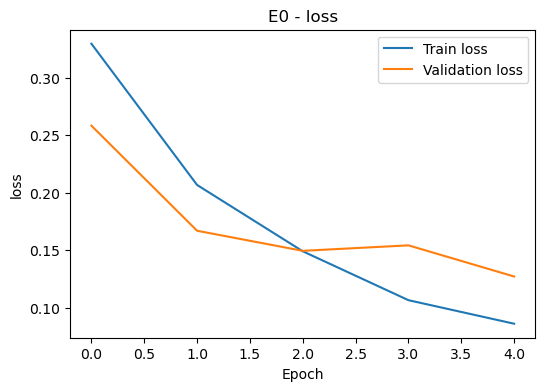

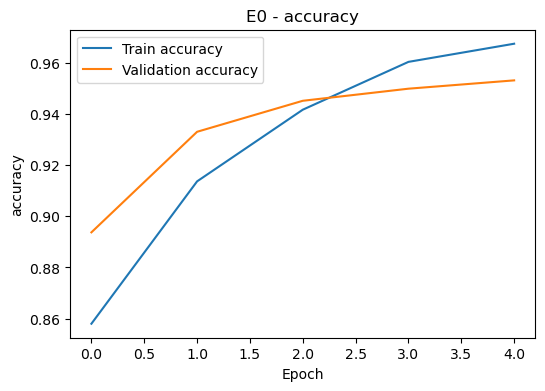

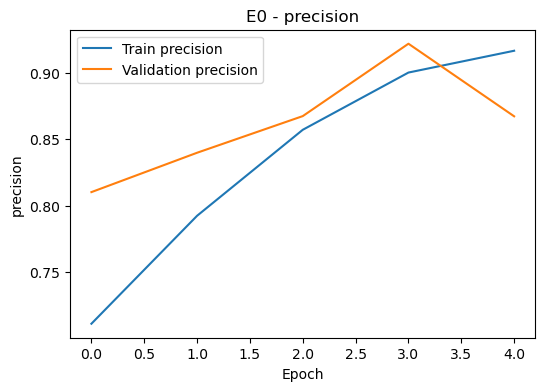

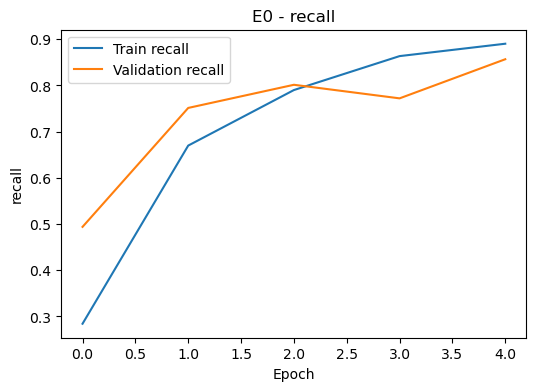

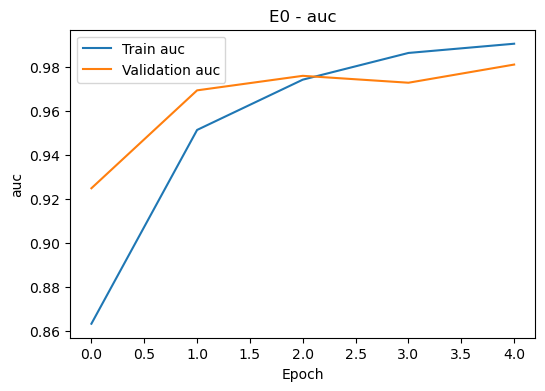

In [16]:
import matplotlib.pyplot as plt

metrics = ["loss", "accuracy", "precision", "recall", "auc"]

for metric in metrics:
    plt.figure(figsize=(6, 4))
    plt.plot(history_e0.history[metric], label=f"Train {metric}")
    plt.plot(history_e0.history[f"val_{metric}"], label=f"Validation {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"E0 - {metric}")
    plt.legend()
    plt.show()

In [19]:
# Sauvegarde du meilleur modèle E0
model_e0.save("E0_CNN_baseline.keras")

In [23]:
import pandas as pd

history_e0_df = pd.DataFrame(history_e0.history)
history_e0_df.index += 1
history_e0_df.index.name = "epoch"

history_e0_df.to_csv("E0_CNN_baseline_history.csv")

history_e0_df


,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
epoch,,,,,,,,,,
1,0.858029,0.863425,0.329704,0.711351,0.284356,0.893711,0.924831,0.258411,0.810198,0.493955
2,0.913621,0.951262,0.206826,0.792434,0.669836,0.932979,0.969209,0.167003,0.839768,0.751295
3,0.941602,0.974054,0.149141,0.857009,0.789974,0.945084,0.975794,0.149542,0.867290,0.801382
4,0.960281,0.986164,0.106606,0.900000,0.863440,0.949808,0.972667,0.154306,0.921649,0.772021
5,0.967368,0.990347,0.086132,0.916370,0.890233,0.953056,0.980898,0.127198,0.867133,0.856649


In [24]:
from sklearn.metrics import classification_report, confusion_matrix

# Prédictions sur le jeu de validation
y_val_proba = model_e0.predict(val_generator)
y_val_pred = (y_val_proba >= 0.5).astype(int).ravel()
y_val_true = val_generator.classes

print(confusion_matrix(y_val_true, y_val_pred))
print(classification_report(
    y_val_true,
    y_val_pred,
    target_names=["Non-COVID", "COVID"]
))

106/106 ━━━━━━━━━━━━━━━━━━━━ 27s 252ms/step
[[2732   76]
 [  83  496]]
              precision    recall  f1-score   support

   Non-COVID       0.97      0.97      0.97      2808
       COVID       0.87      0.86      0.86       579

    accuracy                           0.95      3387
   macro avg       0.92      0.91      0.92      3387
weighted avg       0.95      0.95      0.95      3387



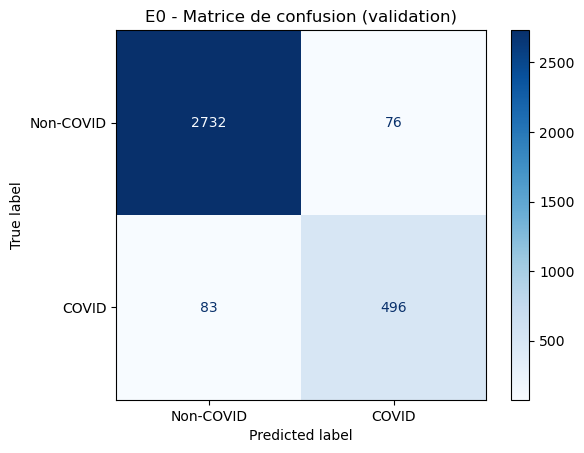

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matrice de confusion sur le jeu de validation
ConfusionMatrixDisplay.from_predictions(
    y_val_true,
    y_val_pred,
    display_labels=["Non-COVID", "COVID"],
    cmap="Blues"
)

plt.title("E0 - Matrice de confusion (validation)")
plt.show()